In [1]:
!pip install kagglehub

In [2]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

fake = pd.read_csv(os.path.join(path, "Fake.csv"))
real = pd.read_csv(os.path.join(path, "True.csv"))

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.


## Adding Labels

In [4]:
fake["label"] = 0   # fake news
real["label"] = 1   # real news

df = pd.concat([fake, real], axis=0)
df = df.sample(frac=1).reset_index(drop=True)  # shuffle

df.head()

,title,text,subject,date,label
0,NFL’S PHONY PATRIOTISM: US Defense Department ...,"Every day, the NFL gives fans another reason t...",left-news,"Oct 7, 2016",0
1,BIG BROTHER? NYC DRIVING PROGRAM TRACKS DRIVERS,Big brother? Tracking drivers and their habit...,Government News,"Sep 5, 2015",0
2,CHILLING! FOX REPORTER JAMES ROSEN Recounts Be...,,politics,"Mar 6, 2017",0
3,What we know so far about the London train bomb,LONDON (Reuters) - An improvised explosive dev...,worldnews,"September 15, 2017",1
4,Sixteen people killed in Russia after train co...,MOSCOW (Reuters) - Sixteen people were killed ...,worldnews,"October 6, 2017",1


In [5]:
df["label"].value_counts()

,count
label,
0,23481
1,21417


## Checking for missing texts

In [6]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


## Text length distribution

In [7]:
df["length"] = df["text"].str.len()
df["length"].describe()

,length
count,44898.000000
mean,2469.109693
std,2171.617091
min,1.000000
25%,1234.000000
50%,2186.000000
75%,3105.000000
max,51794.000000


## Cleaning

In [8]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [9]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop = set(stopwords.words("english"))
lem = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z ]', '', text)
    words = text.split()
    words = [lem.lemmatize(w) for w in words if w not in stop]
    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

In [10]:
df[["text", "clean_text"]].head()

,text,clean_text
0,"Every day, the NFL gives fans another reason t...",every day nfl give fan another reason stop sup...
1,Big brother? Tracking drivers and their habit...,big brother tracking driver habit sound like o...
2,,
3,LONDON (Reuters) - An improvised explosive dev...,london reuters improvised explosive device exp...
4,MOSCOW (Reuters) - Sixteen people were killed ...,moscow reuters sixteen people killed friday tr...


In [ ]:
## Train test split

In [11]:
from sklearn.model_selection import train_test_split

X_text = df["clean_text"]
y = df["label"].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF + Logistic Regression

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Accuracy: 0.9858574610244989
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4696
           1       0.98      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



## Naive Bayes

In [14]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9374164810690423


## Tokenize

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

num_words = 10000
max_len = 300

tokenizer = Tokenizer(num_words=num_words)
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

X_train_dl = pad_sequences(X_train_seq, maxlen=max_len)
X_test_dl  = pad_sequences(X_test_seq, maxlen=max_len)

## GRU Model

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout

model_gru = Sequential()
model_gru.add(Embedding(num_words, 64))
model_gru.add(GRU(32))
model_gru.add(Dropout(0.3))
model_gru.add(Dense(1, activation="sigmoid"))

model_gru.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [17]:
#Early Stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [18]:
#Train
history_gru = model_gru.fit(
    X_train_dl,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.8887 - loss: 0.2614 - val_accuracy: 0.9833 - val_loss: 0.0547
Epoch 2/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9887 - loss: 0.0422 - val_accuracy: 0.9911 - val_loss: 0.0359
Epoch 3/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9933 - loss: 0.0263 - val_accuracy: 0.9827 - val_loss: 0.0487
Epoch 4/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.9934 - loss: 0.0239 - val_accuracy: 0.9907 - val_loss: 0.0305
Epoch 5/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9961 - loss: 0.0147 - val_accuracy: 0.9896 - val_loss: 0.0353


In [19]:
#Evaluate
gru_acc = model_gru.evaluate(X_test_dl, y_test)[1]
print("GRU Accuracy:", gru_acc)

281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9917 - loss: 0.0335
GRU Accuracy: 0.9895322918891907


## Confusion Matrix

281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


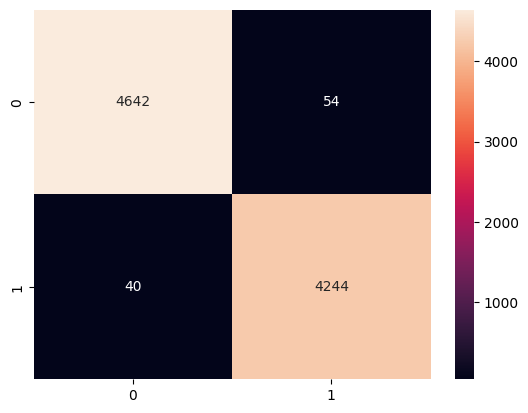

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predict using correct test data
y_pred = (model_gru.predict(X_test_dl) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.show()

print(classification_report(y_test, y_pred))

## ROC Curve + AUC

281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


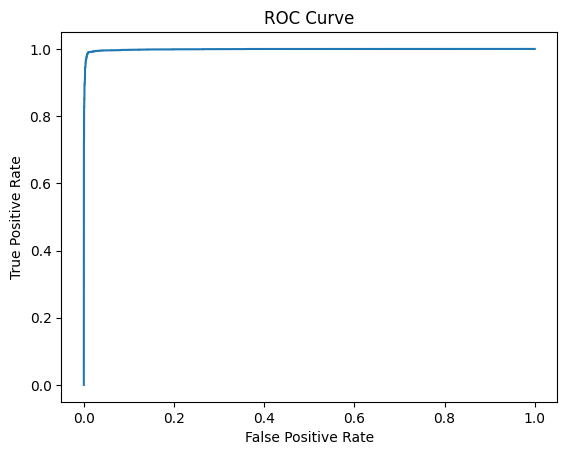

AUC Score: 0.9985855713665366


In [21]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Use correct test data
y_prob = model_gru.predict(X_test_dl).ravel()

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC Score:", roc_auc)

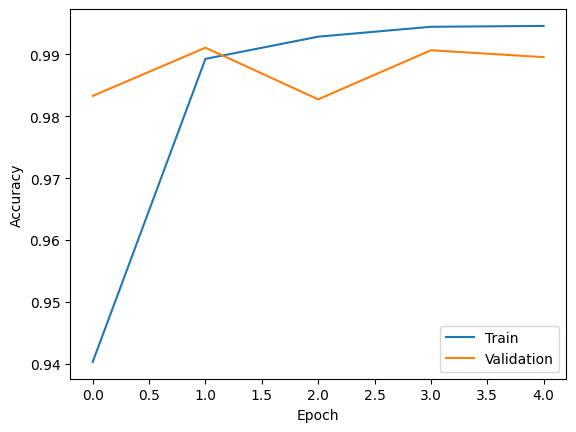

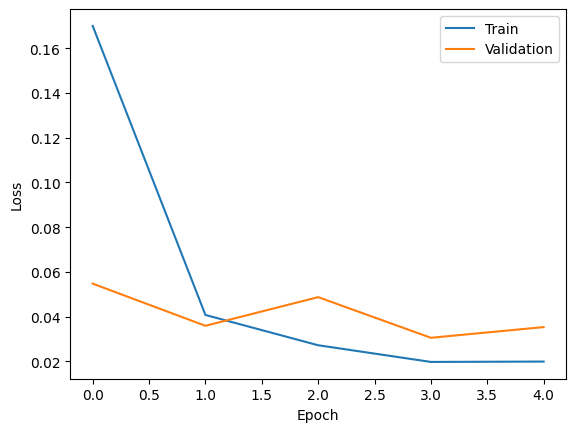

In [22]:
#Learning Curves
import matplotlib.pyplot as plt

plt.plot(history_gru.history["accuracy"])
plt.plot(history_gru.history["val_accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

plt.plot(history_gru.history["loss"])
plt.plot(history_gru.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

## Error Evaluation

In [23]:
import numpy as np

wrong_indices = np.where(y_pred.flatten() != y_test)[0]

print("Total misclassified:", len(wrong_indices))

for i in wrong_indices[:5]:
    print("Actual:", y_test[i])
    print("Predicted:", y_pred[i][0])
    print("Text snippet:", X_test_text.iloc[i][:300])
    print("-----")

Total misclassified: 94
Actual: 0
Predicted: 1
Text snippet: decade ago stood oppression sitting north carolina lunch counter today stand beside donald trump presidentclarence henderson participated sitin protest backing gop candidate despite receiving backlash black community associated press reported donald trump certainly politician politician dime dozen l
-----
Actual: 1
Predicted: 0
Text snippet: reuters zbigniew brzezinski served u president jimmy carter national security adviser iran hostage crisis soviet invasion afghanistan drove normalization relation china died brzezinskis daughter mika host msnbcs morning joe show said father died peacefully friday give cause death known friend zbig g
-----
Actual: 0
Predicted: 1
Text snippet: paying attention america yesterday uk voted leave european union referendum day lord ashcroft surveyed people voted help explain result voted outcome lay behind decisionlord ashcroft poll muslim voted remain ue provides additional refutation claim mad

Most misclassifications occur in neutral-toned articles lacking strong emotional indicators.

## Comparison Table

In [25]:
results = {
    "Naive Bayes": accuracy_score(y_test, y_pred_nb),
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "GRU": gru_acc
}

for model, acc in results.items():
    print(model, ":", round(acc, 4))

Naive Bayes : 0.9374
Logistic Regression : 0.9859
GRU : 0.9895


In [30]:
pip install wordcloud

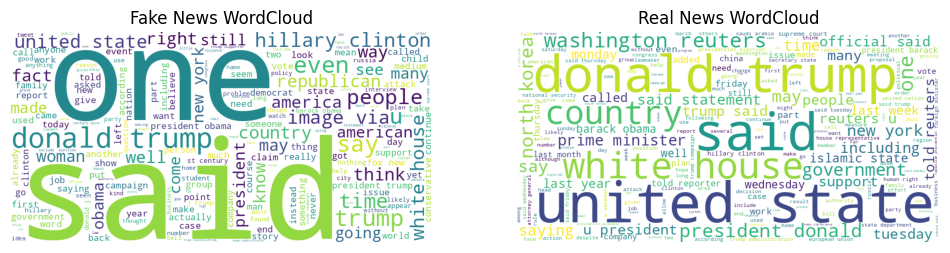

In [26]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fake_text = " ".join(df[df["label"] == 0]["clean_text"])
real_text = " ".join(df[df["label"] == 1]["clean_text"])

wc_fake = WordCloud(width=800, height=400, background_color="white").generate(fake_text)
wc_real = WordCloud(width=800, height=400, background_color="white").generate(real_text)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(wc_fake)
plt.title("Fake News WordCloud")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(wc_real)
plt.title("Real News WordCloud")
plt.axis("off")

plt.show()

In [ ]:
WordCloud analysis reveals that fake news articles often contain emotionally charged and sensational words, while real news articles tend to use formal,
informational, and topic-specific vocabulary. This linguistic contrast highlights how textual tone differs between misinformation and authentic
reporting.

**Conclusion**

In this project, we developed an end-to-end Fake News Detection system using both classical machine learning and deep learning approaches.

Key findings:

TF-IDF + Logistic Regression achieved 98.59% accuracy, proving that classical models perform extremely well on high-dimensional textual data.

The GRU deep learning model achieved 98.95% accuracy with an AUC of 0.9986, slightly outperforming traditional models by capturing sequential dependencies.

Error analysis showed only 94 misclassifications out of 8980 test samples, indicating strong generalization performance.

ROC curve and confusion matrix confirm high precision and recall across both classes.

Although deep learning provided a marginal improvement, classical models were computationally cheaper and nearly as effective. This demonstrates that model selection should balance performance and efficiency.

Overall, the project highlights the importance of:

Proper text preprocessing

Preventing data leakage

Fair model comparison

Detailed evaluation beyond accuracy

This system is robust and can be extended further using transformer-based architectures such as BERT.